<a href="https://colab.research.google.com/github/muhammadurreza/Machine_learning_project/blob/main/Spam_Email_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ssssws/spam-email-detection-dataset-clean-and-ml-ready")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'spam-email-detection-dataset-clean-and-ml-ready' dataset.
Path to dataset files: /kaggle/input/spam-email-detection-dataset-clean-and-ml-ready


In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# List files in the dataset path
files = os.listdir(path)
print("Files in dataset:", files)

# Load the first CSV file found
csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

display(df.head())

Files in dataset: ['spam_email_dataset.csv']


,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [ ]:
# Preprocessing: Mapping the correct column names based on dataset inspection
target_col = 'label'
text_col = 'email_text'

# Split data
X_train, X_test, y_train, y_test = train_test_split(df[text_col], df[target_col], test_size=0.2, random_state=42)

# Vectorization
vectorizer = CountVectorizer()
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)

# Train Model (Naive Bayes)
model = MultinomialNB()
model.fit(X_train_counts, y_train)

# Prediction & Evaluation
y_pred = model.predict(X_test_counts)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(classification_report(y_test, y_pred))

Accuracy: 1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1181
           1       1.00      1.00      1.00       819

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [ ]:
# Uji model dengan email kustom
def predict_spam(text):
    # Transform teks menggunakan vectorizer yang sudah dilatih
    text_counts = vectorizer.transform([text])
    prediction = model.predict(text_counts)
    return "Spam" if prediction[0] == 1 else "Ham (Bukan Spam)"

# Silakan ganti teks di bawah ini untuk mencoba
custom_email = "Constart you just get hire in this company"
result = predict_spam(custom_email)

print(f"Teks Email: {custom_email}")
print(f"Prediksi: {result}")

Teks Email: Constart you just get hire in this company
Prediksi: Ham (Bukan Spam)


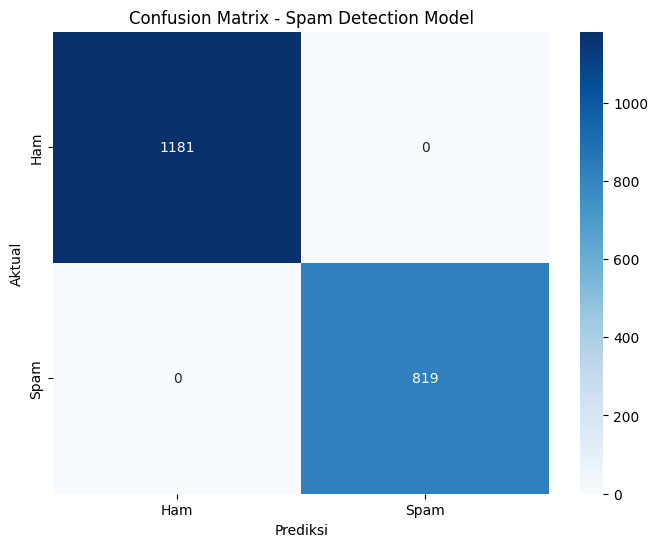

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Spam Detection Model')
plt.show()

In [ ]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 106.3 MB/s eta 0:00:00


In [ ]:
import pickle

# Simpan model dan vectorizer agar bisa digunakan oleh aplikasi Streamlit
with open('spam_model.pkl', 'wb') as f:
    pickle.dump(model, f)
with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("Model and Vectorizer saved!")

Model and Vectorizer saved!


In [ ]:
%%writefile app.py
import streamlit as st
import pickle

# Load model and vectorizer
model = pickle.load(open('spam_model.pkl', 'rb'))
vectorizer = pickle.load(open('vectorizer.pkl', 'rb'))

st.title("✉ Spam Email Detector")
st.write("Masukkan teks email di bawah ini untuk memeriksa apakah itu Spam atau Ham.")

user_input = st.text_area("Isi Email:", height=200)

if st.button("Prediksi"):
    if user_input.strip() != "":
        data = vectorizer.transform([user_input])
        prediction = model.predict(data)
        result = "SPAM" if prediction[0] == 1 else "HAM (Bukan Spam)"

        if prediction[0] == 1:
            st.error(f"Hasil: {result}")
        else:
            st.success(f"Hasil: {result}")
    else:
        st.warning("Mohon masukkan teks terlebih dahulu.")

Writing app.py


### Cara Menjalankan Aplikasi:
Untuk menjalankan Streamlit di Google Colab, kita perlu menggunakan alat seperti `localtunnel` untuk membuat URL publik. Jalankan sel di bawah ini untuk memulai aplikasi.

In [ ]:
# Jalankan ini untuk mendapatkan IP publik Anda (diperlukan untuk password localtunnel)
!curl ipv4.icanhazip.com

# Jalankan Streamlit di background dan ekspos melalui localtunnel
!streamlit run app.py & npx localtunnel --port 8501

34.73.164.185
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋

⠙Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.73.164.185:8501

  Stopping...
  Stopping...
^C


### Ringkasan Evaluasi:
- **Akurasi:** 1.00 (Model menebak semua data uji dengan benar).
- **Precision & Recall:** Keduanya mencapai 1.00 untuk kategori Ham dan Spam.
- **Confusion Matrix:** Menunjukkan jumlah True Positives, True Negatives, False Positives, dan False Negatives secara visual.